# QUEST 5
__Boxplot__

In [175]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

database_path = "../data/ab-test.csv"

In [176]:
try:
    connection = sqlite3.connect(database_path)
except Exception:
    print("Не удалось подключиться к СУБД :(")

In [177]:
df = pd.read_csv(database_path)
display(df)

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [178]:
df_before = df[df["time"] == "before"].reset_index(drop=True).drop("time", axis=1)
df_after = df[df["time"] == "after"].reset_index(drop=True).drop("time", axis=1)
del df

In [179]:
display(df_before)

,uid,diff,group
0,user_1,-6.000000,test
1,user_18,-3.500000,test
2,user_19,-148.000000,test
3,user_21,-112.500000,test
4,user_25,-69.333333,test
5,user_28,-53.000000,test
6,user_3,-70.000000,test
7,user_12,-103.000000,control
8,user_13,-15.500000,control
9,user_15,-3.000000,control


In [180]:
display(df_after)

,uid,diff,group
0,user_1,-103.333333,test
1,user_18,-10.000000,test
2,user_19,-82.333333,test
3,user_21,-78.500000,test
4,user_25,-127.500000,test
5,user_28,-136.500000,test
6,user_3,-158.500000,test
7,user_12,-75.000000,control
8,user_13,-81.500000,control
9,user_15,-32.000000,control


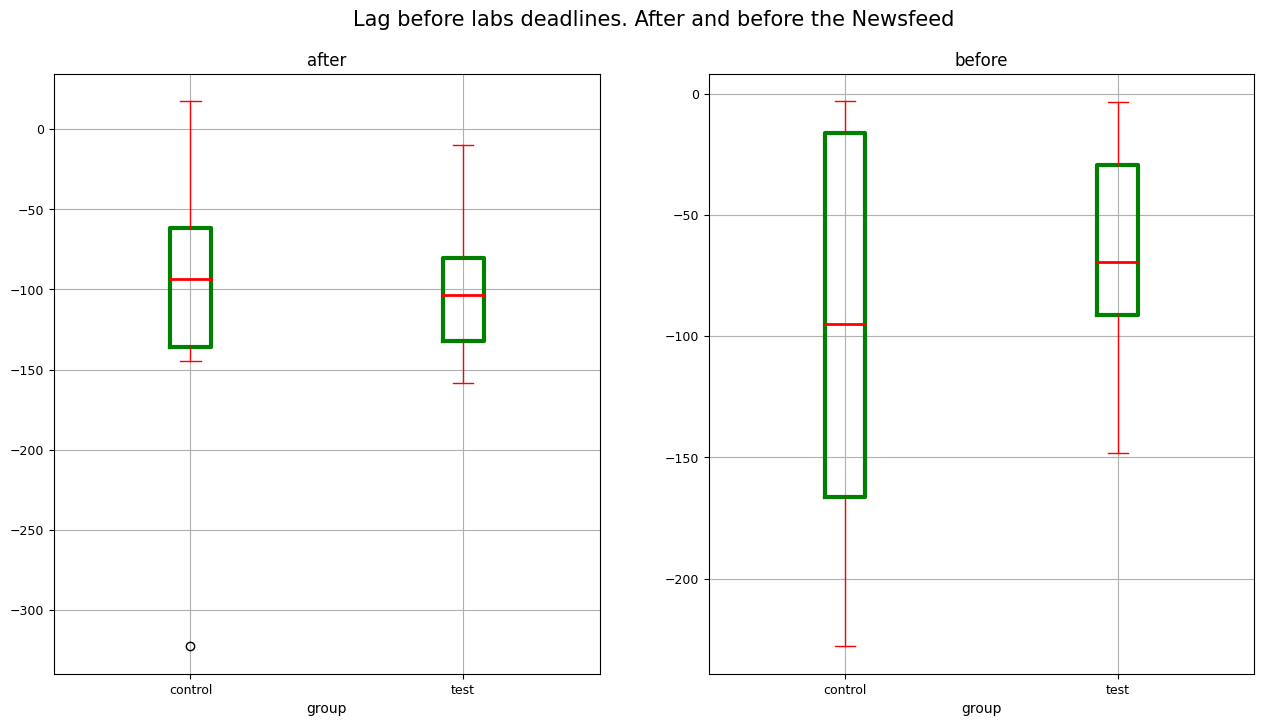

In [181]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches((15, 8))
# коробочки before
df_before.boxplot(ax=ax[1], column="diff", by="group", fontsize=9, 
                  medianprops={"linewidth":2, "color":"red"}, 
                  boxprops={"linewidth":3, "color":"green"},
                  whiskerprops={"color":"red"},
                  capprops={"color":"red"}
                  )
# коробочки after
df_after.boxplot(ax=ax[0], column="diff", by="group", fontsize=9, 
                 medianprops={"linewidth":2, "color":"red"},        # медианы
                 boxprops={"linewidth":3, "color":"green"},         # границы коробочек
                 whiskerprops={"color":"red"},                      # вертикальные линии
                 capprops={"color":"red"}                           # концы вертикальных линий
                 ) 
ax[0].set_title("after")
ax[1].set_title("before")
fig.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)
plt.show()

## What was the IQR of the control group before the newsfeed? - 150

In [182]:
df_before[df_before["group"] == "control"].describe()

,diff
count,15.000000
mean,-98.033333
std,80.326225
min,-228.000000
25%,-166.250000
50%,-95.000000
75%,-16.250000
max,-3.000000


In [183]:
Q1 = df_before[df_before["group"] == "control"].describe()["diff"]["25%"]  # 25% данных ниже Q1
Q3 = df_before[df_before["group"] == "control"].describe()["diff"]["75%"]  
iqr = Q3 - Q1
print(f"Q1 = {Q1}   Q3 = {Q3}")
print(f"iqr = {iqr}")

Q1 = -166.25   Q3 = -16.25
iqr = 150.0


In [184]:
connection.close()